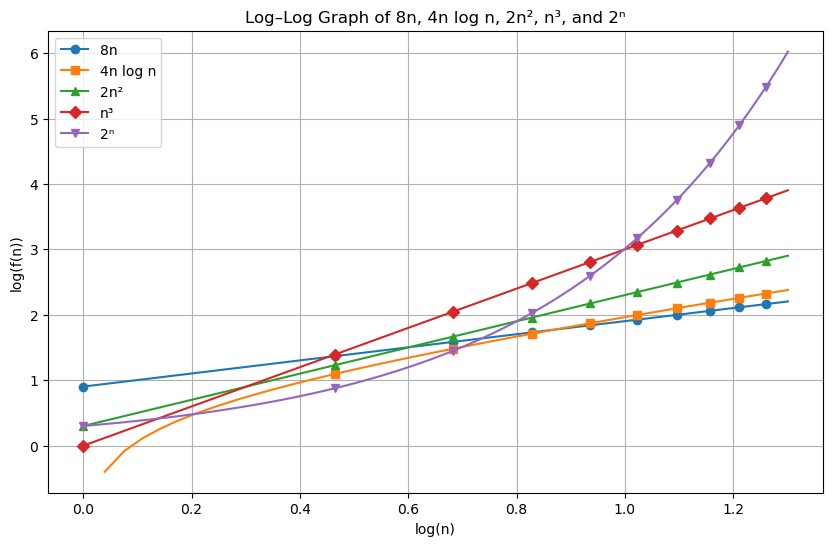

In [1]:
#C3.1
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
n = np.linspace(1, 20, 200)
f1 = 8 * n
f2 = 4 * n * np.log(n)
f3 = 2 * n**2
f4 = n**3
f5 = 2**n
log_n = np.log10(n)
log_f1 = np.log10(f1)
log_f2 = np.log10(f2)
log_f3 = np.log10(f3)
log_f4 = np.log10(f4)
log_f5 = np.log10(f5)
plt.figure(figsize=(10, 6))
plt.plot(log_n, log_f1, label='8n', marker='o', markevery=20)
plt.plot(log_n, log_f2, label='4n log n', marker='s', markevery=20)
plt.plot(log_n, log_f3, label='2n²', marker='^', markevery=20)
plt.plot(log_n, log_f4, label='n³', marker='D', markevery=20)
plt.plot(log_n, log_f5, label='2ⁿ', marker='v', markevery=20)
plt.xlabel('log(n)')
plt.ylabel('log(f(n))')
plt.title('Log–Log Graph of 8n, 4n log n, 2n², n³, and 2ⁿ')
plt.legend()
plt.grid(True)
plt.show()

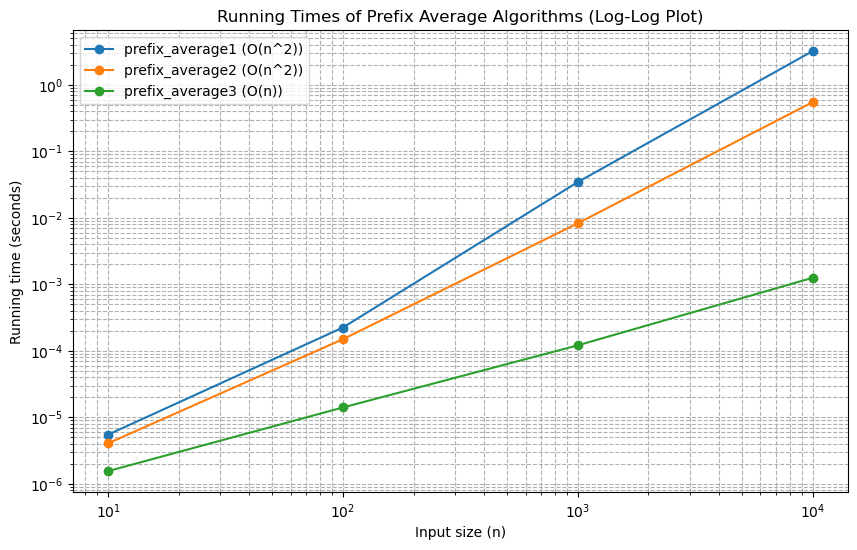

In [2]:
#C3.55
import time
import random
import matplotlib.pyplot as plt
import numpy as np
def prefix_average1(S):
    n=len(S)
    A=[0]*n
    for j in range(n):
        total=0
        for i in range(j+1):
            total+=S[i]
        A[j]=total/(j+1)
    return A
def prefix_average2(S):
    n=len(S)
    A=[0]*n
    for j in range(n):
        A[j]=sum(S[:j+1])/(j+1)
    return A
def prefix_average3(S):
    n=len(S)
    A=[0]*n
    total=0
    for j in range(n):
        total+=S[j]
        A[j]=total/(j+1)
    return A
def time_function(func,S,trials=10):
    times=[]
    for _ in range(trials):
        start=time.perf_counter()
        func(S)
        end=time.perf_counter()
        times.append(end-start)
    return np.mean(times)
sizes=[10,100,1000,10000]
times1=[]
times2=[]
times3=[]
for n in sizes:
    S=[random.random() for _ in range(n)]
    times1.append(time_function(prefix_average1,S))
    times2.append(time_function(prefix_average2,S))
    times3.append(time_function(prefix_average3,S))
plt.figure(figsize=(10,6))
plt.loglog(sizes,times1,'o-',label="prefix_average1 (O(n^2))")
plt.loglog(sizes,times2,'o-',label="prefix_average2 (O(n^2))")
plt.loglog(sizes,times3,'o-',label="prefix_average3 (O(n))")
plt.xlabel("Input size (n)")
plt.ylabel("Running time (seconds)")
plt.title("Running Times of Prefix Average Algorithms (Log-Log Plot)")
plt.legend()
plt.grid(True,which="both",ls="--")
plt.show()

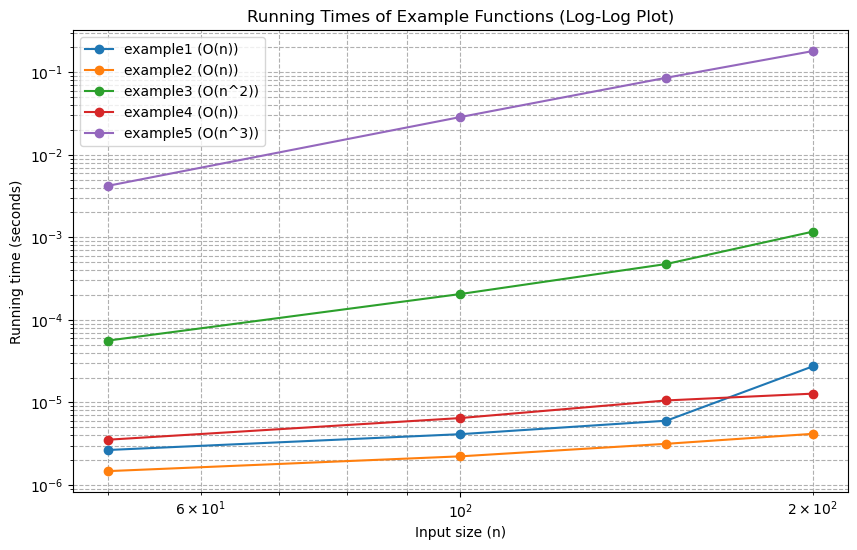

In [26]:
#C3.56
import time
import random
import matplotlib.pyplot as plt
import numpy as np
def example1(S):
    n=len(S)
    total=0
    for j in range(n):
        total+=S[j]
    return total
def example2(S):
    n=len(S)
    total=0
    for j in range(0,n,2):
        total+=S[j]
    return total
def example3(S):
    n=len(S)
    total=0
    for j in range(n):
        for k in range(1+j):
            total+=S[k]
    return total
def example4(S):
    n=len(S)
    prefix=0
    total=0
    for j in range(n):
        prefix+=S[j]
        total+=prefix
    return total
def example5(A,B):
    n=len(A)
    count=0
    for i in range(n):
        total=0
        for j in range(n):
            for k in range(1+j):
                total+=A[k]
        if B[i]==total:
            count+=1
    return count
def time_function(f,arg,T=10):
    times=[]
    for _ in range(T):
        start=time.perf_counter()
        f(arg)
        end=time.perf_counter()
        times.append(end-start)
    return np.mean(times)
sizes=[50,100,150,200]
times_ex1=[]
times_ex2=[]
times_ex3=[]
times_ex4=[]
times_ex5=[]
for n in sizes:
    S=[random.randint(0,100) for _ in range(n)]
    times_ex1.append(time_function(example1,S))
    times_ex2.append(time_function(example2,S))
    times_ex3.append(time_function(example3,S))
    times_ex4.append(time_function(example4,S))
for n in sizes:
    A=[random.randint(0,10) for _ in range(n)]
    B=[random.randint(0,1000) for _ in range(n)]
    times_ex5.append(time_function(lambda pair: example5(pair[0],pair[1]),(A,B)))
plt.figure(figsize=(10,6))
plt.loglog(sizes,times_ex1,'o-',label="example1 (O(n))")
plt.loglog(sizes,times_ex2,'o-',label="example2 (O(n))")
plt.loglog(sizes,times_ex3,'o-',label="example3 (O(n^2))")
plt.loglog(sizes,times_ex4,'o-',label="example4 (O(n))")
plt.loglog(sizes,times_ex5,'o-',label="example5 (O(n^3))")
plt.xlabel("Input size (n)")
plt.ylabel("Running time (seconds)")
plt.title("Running Times of Example Functions (Log-Log Plot)")
plt.legend()
plt.grid(True,which="both",ls="--")
plt.show()

In [33]:
#C3.58
import time,random
def unique1(S):
    for j in range(len(S)):
        for k in range(j+1, len(S)):
            if S[j] == S[k]:
                return False
    return True
def unique2(S):
    temp = sorted(S)
    for j in range(1, len(temp)):
        if temp[j-1] == temp[j]:
            return False
    return True
def unique3(S):
    seen = set()
    for x in S:
        if x in seen:
            return False
        seen.add(x)
    return True
def time_function(f,S):
    start=time.perf_counter()
    f(S)
    return time.perf_counter()-start
def find_max_n(func,start=10,limit=0.001,max_n=10**5):
    n=start
    last_n=n
    while n<=max_n:
        S=list(range(n))
        random.shuffle(S)
        t=time_function(func,S)
        if t>limit:
            return last_n
        last_n=n
        n*=2
    return last_n
print("unique1 max n (<= 0.001 sec):",find_max_n(unique1))
print("unique2 max n (<= 0.001 sec):",find_max_n(unique2))
print("unique3 max n (<= 0.001 sec):",find_max_n(unique3))

unique1 max n (<= 0.001 sec): 160
unique2 max n (<= 0.001 sec): 1280
unique3 max n (<= 0.001 sec): 10240
